<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke08-etikk-implementering/04_ai_etikk_i_medisinen.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 10-25 min
- **Datamønster:** `synthetic-or-inline`

**Krav før kjøring:**
- API: ikke nødvendig
- Data: syntetisk eller innebygd i notebooken
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. I Colab hentes hemmeligheter fra **Secrets** med `userdata.get(...)`; lokalt brukes miljøvariabler eller `.env`.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.


In [ ]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = []
COLAB_DATA_MODE = 'synthetic-or-inline'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


# AI-etikk i medisinen

> **"Det viktigste spørsmålet er ikke bare om AI virker, men om den brukes på en måte som er forsvarlig for pasienter, klinikere og samfunnet."**

Denne notebooken samler trådene fra uke 08 og ser personvern, bias, ansvar og kliniske dilemmaer i sammenheng. Målet er ikke å gi ett enkelt riktig svar, men å gi deg et språk og et rammeverk for å analysere vanskelige valg når AI tas i bruk i helse og medisin.

> **Merk:** Dette er pedagogisk materiale for læring og refleksjon. Det er ikke juridisk rådgivning eller en fasit for kliniske beslutninger.

## 🎯 Hva du lærer i dag

✅ anvende sentrale medisinsk-etiske prinsipper på AI i helse  
✅ identifisere etiske dilemmaer i kliniske AI-systemer  
✅ forklare hvordan bias, personvern og ansvar henger sammen i praksis  
✅ bruke en enkel vurderingsramme for å drøfte om et AI-system bør tas i bruk  

## 📚 Innhold

1. Hvorfor AI-etikk i helse er et eget spørsmål  
2. De fire medisinsk-etiske prinsippene  
3. Kliniske dilemmaer i praksis  
4. En enkel etisk sjekkliste  
5. Bias, personvern og ansvar i sammenheng  
6. Refleksjon og oppsummering

### Men først: 🔧 miljøoppsett – kode skal fungere både lokalt og i Google Colab

In [1]:
import sys
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Kjører i Google Colab")
    !pip install seaborn --quiet
    if not os.path.exists('AI-og-helse'):
        try:
            !git clone https://github.com/arvidl/AI-og-helse.git
            print("✅ Repository klonet")
        except Exception:
            print("⚠️ Kunne ikke klone repository automatisk")
    if os.path.exists('AI-og-helse'):
        os.chdir('AI-og-helse')
        print(f"📁 Arbeidsmappe: {os.getcwd()}")
else:
    print("💻 Kjører i lokalt miljø")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ Miljøet er konfigurert")
print(f"🎲 Random seed satt til {RANDOM_SEED}")

💻 Kjører i lokalt miljø
✅ Miljøet er konfigurert
🎲 Random seed satt til 42


## 1. Hvorfor AI-etikk i helse er et eget spørsmål

AI i helse skiller seg fra mange andre AI-bruksområder fordi konsekvensene av feil kan være alvorlige: forsinket diagnose, feilprioritering, svekket tillit eller dårligere behandling for enkelte pasientgrupper.

Denne notebooken er ment som en **syntese**, ikke som en erstatning for de tidligere notebookene i uke 08:

- `01_gdpr_personvern.ipynb` går dypere inn i juridiske og praktiske personvernspørsmål
- `02_bias_rettferdighet.ipynb` går dypere inn i typer bias, fairness og måling
- `03_ce_mdr_regulering.ipynb` går dypere inn i regulering, CE-merking og ansvar ved innføring

Her er målet å se disse temaene samlet i klinisk praksis.

Derfor holder det ikke å spørre om modellen er **treffsikker**. Vi må også spørre:

- Hvem gagner systemet?
- Hvem risikerer å bli skadelidende?
- Hvilke data bygger systemet på?
- Hvem har ansvar når anbefalingene blir brukt i praksis?

Dette er grunnen til at etikk, personvern, bias og ansvar må sees i sammenheng.

## 2. De fire medisinsk-etiske prinsippene

En nyttig start er å tolke AI i lys av de klassiske prinsippene i medisinsk etikk:

| Prinsipp | Tradisjonell betydning | Viktige spørsmål for AI i helse |
|---|---|---|
| **Autonomi** | Pasienten skal kunne forstå og medvirke | Vet pasienten at AI brukes? Er informasjonen forståelig? |
| **Velgjørenhet** | Tiltak skal gagne pasienten | Gir AI faktisk bedre beslutningsstøtte eller bedre ressursbruk? |
| **Ikke-skade** | Vi skal unngå å påføre skade | Hva skjer når modellen tar feil? Hvem fanger opp feilene? |
| **Rettferdighet** | Likeverdig behandling og rimelig fordeling | Fungerer AI like godt for ulike pasientgrupper? |

> **Poenget er ikke at AI erstatter etisk vurdering, men at AI gjør den etiske vurderingen mer nødvendig.**

## 3. Kliniske dilemmaer i praksis

### Case 1: Triage og ressursfordeling
Et AI-system estimerer hvem som har størst nytte av intensiv behandling under press på kapasiteten. Skal den høyest estimerte nytten alltid styre prioriteringen?

### Case 2: Pasientautonomi mot AI-anbefaling
En pasient ønsker en annen løsning enn det AI-systemet og behandleren anbefaler. Hvordan balanseres pasientens autonomi mot en sterk risikomodell?

### Case 3: Høy ytelse, lav forklarbarhet
En modell er mer treffsikker enn klinikere på et smalt område, men det er vanskelig å forklare hvorfor den anbefaler det den gjør. Er dette etisk akseptabelt?

### Case 4: Informasjon til pasienten
Når bør pasienter få vite at AI inngår i vurderingen, og hvordan kan dette kommuniseres på en trygg og forståelig måte?

> Det finnes sjelden ett riktig svar. Målet er å øve opp systematisk etisk resonnering.

In [2]:
# En enkel vurderingsramme for AI i helse

def etisk_sjekkliste(systemnavn: str):
    sjekkliste = {
        "Transparens": [
            "Er det tydelig for brukere og pasienter at AI brukes?",
            "Kan begrensninger og feilkilder forklares på en forståelig måte?",
            "Er treningsgrunnlag og validering dokumentert?"
        ],
        "Rettferdighet": [
            "Er ytelse undersøkt for ulike pasientgrupper?",
            "Finnes det kjent skjevhet i data eller modell?",
            "Er konsekvenser av feil ulikt fordelt mellom grupper?"
        ],
        "Personvern": [
            "Brukes bare data som er nødvendige for formålet?",
            "Er det klart hvilket rettslig grunnlag og hvilket formål som gjelder?",
            "Er det vurdert hvordan data lagres, deles og eventuelt slettes?"
        ],
        "Ansvar": [
            "Hvem har ansvar når AI brukes i kliniske beslutninger?",
            "Kan en kliniker overstyre eller ignorere AI-anbefalingen?",
            "Finnes det logging og mulighet for etterprøving?"
        ],
        "Sikkerhet": [
            "Hva skjer hvis systemet tar feil eller er usikkert?",
            "Finnes det fallback-rutiner uten AI?",
            "Er systemet testet i realistiske kliniske situasjoner?"
        ]
    }

    print("═" * 68)
    print(f"ETISK SJEKKLISTE FOR: {systemnavn}")
    print("═" * 68)
    for kategori, spørsmål in sjekkliste.items():
        print(f"\n📌 {kategori}")
        print("-" * 50)
        for nr, spørsmålstekst in enumerate(spørsmål, start=1):
            print(f"  □ {nr}. {spørsmålstekst}")

etisk_sjekkliste("AI-basert beslutningsstøtte for radiologi")

════════════════════════════════════════════════════════════════════
ETISK SJEKKLISTE FOR: AI-basert beslutningsstøtte for radiologi
════════════════════════════════════════════════════════════════════

📌 Transparens
--------------------------------------------------
  □ 1. Er det tydelig for brukere og pasienter at AI brukes?
  □ 2. Kan begrensninger og feilkilder forklares på en forståelig måte?
  □ 3. Er treningsgrunnlag og validering dokumentert?

📌 Rettferdighet
--------------------------------------------------
  □ 1. Er ytelse undersøkt for ulike pasientgrupper?
  □ 2. Finnes det kjent skjevhet i data eller modell?
  □ 3. Er konsekvenser av feil ulikt fordelt mellom grupper?

📌 Personvern
--------------------------------------------------
  □ 1. Brukes bare data som er nødvendige for formålet?
  □ 2. Er det klart hvilket rettslig grunnlag og hvilket formål som gjelder?
  □ 3. Er det vurdert hvordan data lagres, deles og eventuelt slettes?

📌 Ansvar
------------------------------

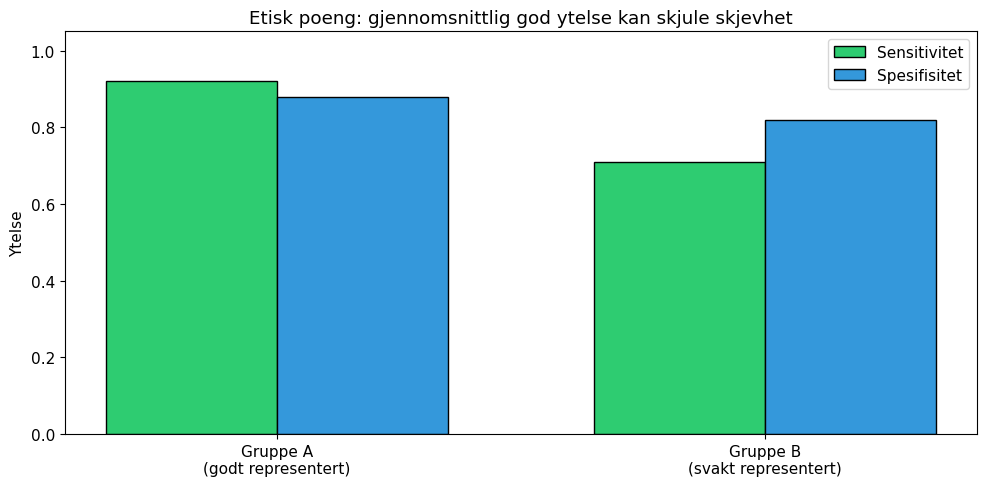

Konsekvensen er ikke bare teknisk. Hvis én gruppe får flere falske negative funn,
kan det bety forsinket diagnose, senere behandling og systematisk urettferdighet.


In [3]:
# Eksempel: samme modell kan gi ulik klinisk konsekvens for ulike grupper

grupper = ["Gruppe A\n(godt representert)", "Gruppe B\n(svakt representert)"]
sensitivitet = [0.92, 0.71]
spesifisitet = [0.88, 0.82]

x = np.arange(len(grupper))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, sensitivitet, width, label="Sensitivitet", color="#2ecc71", edgecolor="black")
ax.bar(x + width/2, spesifisitet, width, label="Spesifisitet", color="#3498db", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(grupper)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Ytelse")
ax.set_title("Etisk poeng: gjennomsnittlig god ytelse kan skjule skjevhet")
ax.legend()
plt.tight_layout()
plt.show()

print("Konsekvensen er ikke bare teknisk. Hvis én gruppe får flere falske negative funn,")
print("kan det bety forsinket diagnose, senere behandling og systematisk urettferdighet.")

## 4. Bias, personvern og ansvar henger sammen

Det er lett å behandle disse temaene som tre forskjellige problemer:

- **Bias** blir et spørsmål om modellkvalitet
- **Personvern** blir et spørsmål om lovverk
- **Ansvar** blir et spørsmål om organisering

I praksis henger de tett sammen.

Eksempel:

- Hvis modellen er trent på et skjevt datasett, får enkelte grupper dårligere beslutningsstøtte.
- Hvis pasientdata brukes uklart eller for bredt, svekkes tilliten til systemet.
- Hvis det ikke er klart hvem som har ansvar for overstyring, oppfølging og feil, kan klinikeren bli stående alene med risikoen.

Etisk vurdering av AI i helse handler derfor ikke bare om å spørre **"virker modellen?"**, men også **"for hvem virker den?"**, **"på hvilke premisser?"** og **"hvem bærer konsekvensene når den ikke virker?"**.

## 5. Refleksjonsspørsmål

1. Når er det etisk forsvarlig å la AI få stor innflytelse på en klinisk beslutning?
2. Hva er viktigst å kommunisere til pasienten når AI har vært brukt i vurderingen?
3. Hvis en modell fungerer dårligere for én pasientgruppe, er det da nok å informere om dette, eller må systemet endres eller trekkes tilbake?
4. Hvem bør ha ansvar for å oppdage at en modell ikke lenger fungerer godt etter at den er tatt i bruk?
5. Hvordan skiller etisk vurdering seg fra ren juridisk og teknisk vurdering?

## 6. Oppsummering

Det viktigste poenget i denne notebooken er at AI-etikk i helse ikke er et tillegg som kommer etterpå. Den må være en del av hvordan systemet designes, valideres, tas i bruk og følges opp.

Hvis du skal sitte igjen med tre spørsmål, kan det være disse:

- Hvem hjelper systemet?
- Hvem kan bli skadet av det?
- Hvem har ansvar når det brukes i praksis?

I neste notebook går vi ett steg videre og ser på hva som faktisk gjør et AI-system **tillitsverdig** i klinisk bruk: robusthet, usikkerhet, human-in-the-loop, validering og monitorering.